# Online Training of MLP and CNN Models Using EKF and CMGF

## Overview
This project explores **sequential Bayesian learning** for **MLP** and **CNN** models using **Extended Kalman Filter (EKF)** and **Conditional Moments Gaussian Filter (CMGF)**. These methods update model parameters adaptively, treating them as evolving states with Gaussian drift.

## 1. Training MLP with Spiral Dataset
- An **MLP classifier** is trained on a **spiral dataset** using **EKF & CMGF**.
- The model adapts to a **rotated version** of the dataset by leveraging prior knowledge.

## 2. Extending to CNN with MNIST Dataset
- A **CNN** is trained to classify **MNIST digits 0 and 1**.
- Convolutional layers are **frozen**, and fully connected layers are retrained for **digits 2 and 3**, ensuring efficient transfer learning.

## Model Formulation
\begin{align*}
\theta_t &=  \theta_{t-1} + q_t, \; q_t \sim N(0, 0.01 I)  \\  
y_t &\sim Ber(\sigma(h(x_t, \theta_t)))
\end{align*}
- **EKF** linearizes updates, while **CMGF** maintains mean & covariance for adaptive learning.

For details, see **Sec 8.7.7** of [Probabilistic Machine Learning: Advanced Topics](https://probml.github.io/pml-book/book2.html).

## Graphical Model & Training Visualization
![RLS](https://github.com/probml/dynamax/blob/main/docs/figures/rlsDgm.png?raw=true)  
Training video can be found at [Training Video](https://gist.github.com/petergchang/9441b853b889e0b47d0622da8f7fe2f6)


In [ ]:
# CLone the project from github
!git clone https://github.com/VarunBiyyala/cnn_ekf.git

Cloning into 'cnn_ekf'...
remote: Enumerating objects: 19, done.
remote: Counting objects: 100% (19/19), done.
remote: Compressing objects: 100% (16/16), done.
remote: Total 19 (delta 3), reused 14 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (19/19), 19.17 KiB | 594.00 KiB/s, done.
Resolving deltas: 100% (3/3), done.


In [ ]:
# Install require packaages and libraries
!pip install -r cnn_ekf/requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.7/155.7 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.8/317.8 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 84.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 3.8 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2


In [ ]:
# Importing necessary libraries and packages
print_verbose = False
from dynamax.generalized_gaussian_ssm import ParamsGGSSM, EKFIntegrals
from dynamax.generalized_gaussian_ssm import conditional_moments_gaussian_filter
from typing import Sequence
from functools import partial

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import jax
import random
import seaborn as sns
import jax.numpy as jnp
import numpy as np
import jax.random as jr
from jax.flatten_util import ravel_pytree

import cnn_ekf.my_package
from cnn_ekf.my_package import *

### Generating and Visualizing Spiral Data

- We generate a spiral-shaped dataset for binary classification using the `generate_spiral_dataset()` function. The dataset consists of two interleaved spirals, making it a challenging non-linear classification problem.

- The generated data is then plotted using `plot_posterior_predictive()`, which visualizes class distributions and decision boundaries.


<Axes: title={'center': 'Spiral-shaped binary classification data'}>

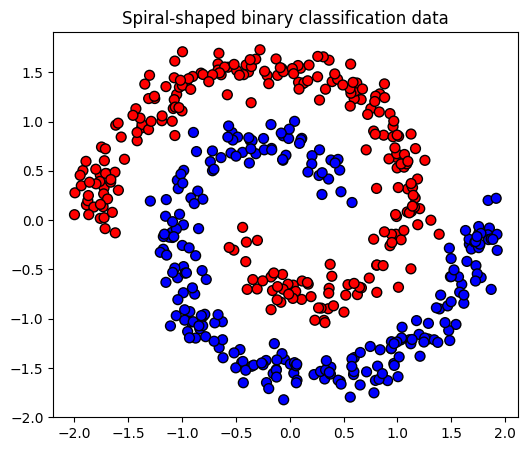

In [ ]:
# Generate data
input, output = generate_spiral_dataset()

# Plot data
fig, ax = plt.subplots(figsize=(6, 5))

title = "Spiral-shaped binary classification data"
plot_posterior_predictive(ax, input, output, title)

## 1. MLP Training with Conditional Moments Gaussian Filter (CMGF)

We train a Multi-Layer Perceptron (MLP) classifier using the Extended Kalman Filter (EKF) for sequential Bayesian inference. The `MLP_EKF_Training` class initializes an MLP model, flattens its parameters, and applies the CMGF-based EKF for recursive parameter updates.

**The training process involves:**
- Initializing an MLP with specified layer dimensions.
- Using CMGF to perform approximate inference on model parameters.
- Updating the parameters based on observed data.

This approach enables online learning, adapting the model parameters dynamically over time.


In [ ]:
from cnn_ekf.scripts.mlp_ekf_training import MLP_EKF_Training

# Create an instance of CNN_EKF_Training
mlp_ekf_training = MLP_EKF_Training()

model_dims = [2, 16, 16, 1]

# Run the EKF
w_means, w_covs, sigmoid_fn = mlp_ekf_training.run_mlp_ekf(output, input)

## 1.1 Evaluating the Trained MLP Classifier  

- After training the MLP using the Conditional Moments Gaussian Filter (CMGF) with EKF, we evaluate its performance on a grid of input values. The function `posterior_predictive_grid()` computes the model's predicted outputs using the final parameter estimates.

- The results are then visualized using `plot_posterior_predictive()`, which displays the decision boundary and class distributions, providing insight into the classifier’s learned representation.


In [ ]:
# Define grid limits
xmin, ymin = input.min(axis=0) - 0.1
xmax, ymax = input.max(axis=0) + 0.1

# Define grid
step = 0.1
x_grid, y_grid = jnp.meshgrid(jnp.mgrid[xmin:xmax:step], jnp.mgrid[ymin:ymax:step])
input_grid = jnp.concatenate([x_grid[...,None], y_grid[...,None]], axis=2)

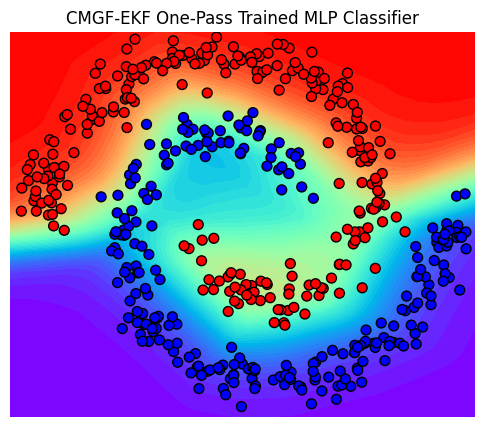

In [ ]:
# Evaluate the trained MLP on input_grid
Z = posterior_predictive_grid(input_grid, w_means[-1], sigmoid_fn, binary=False)

# Plot the final result
fig, ax = plt.subplots(figsize=(6, 5))
title = "CMGF-EKF One-Pass Trained MLP Classifier"
plot_posterior_predictive(ax, input, output, title, input_grid, Z);

## 1.2 Plotting Weight Convergence and Layer Weights  

The helper functions visualize the convergence of weight estimates during training and plot the weights of individual layers, helping track model parameter changes over time.  


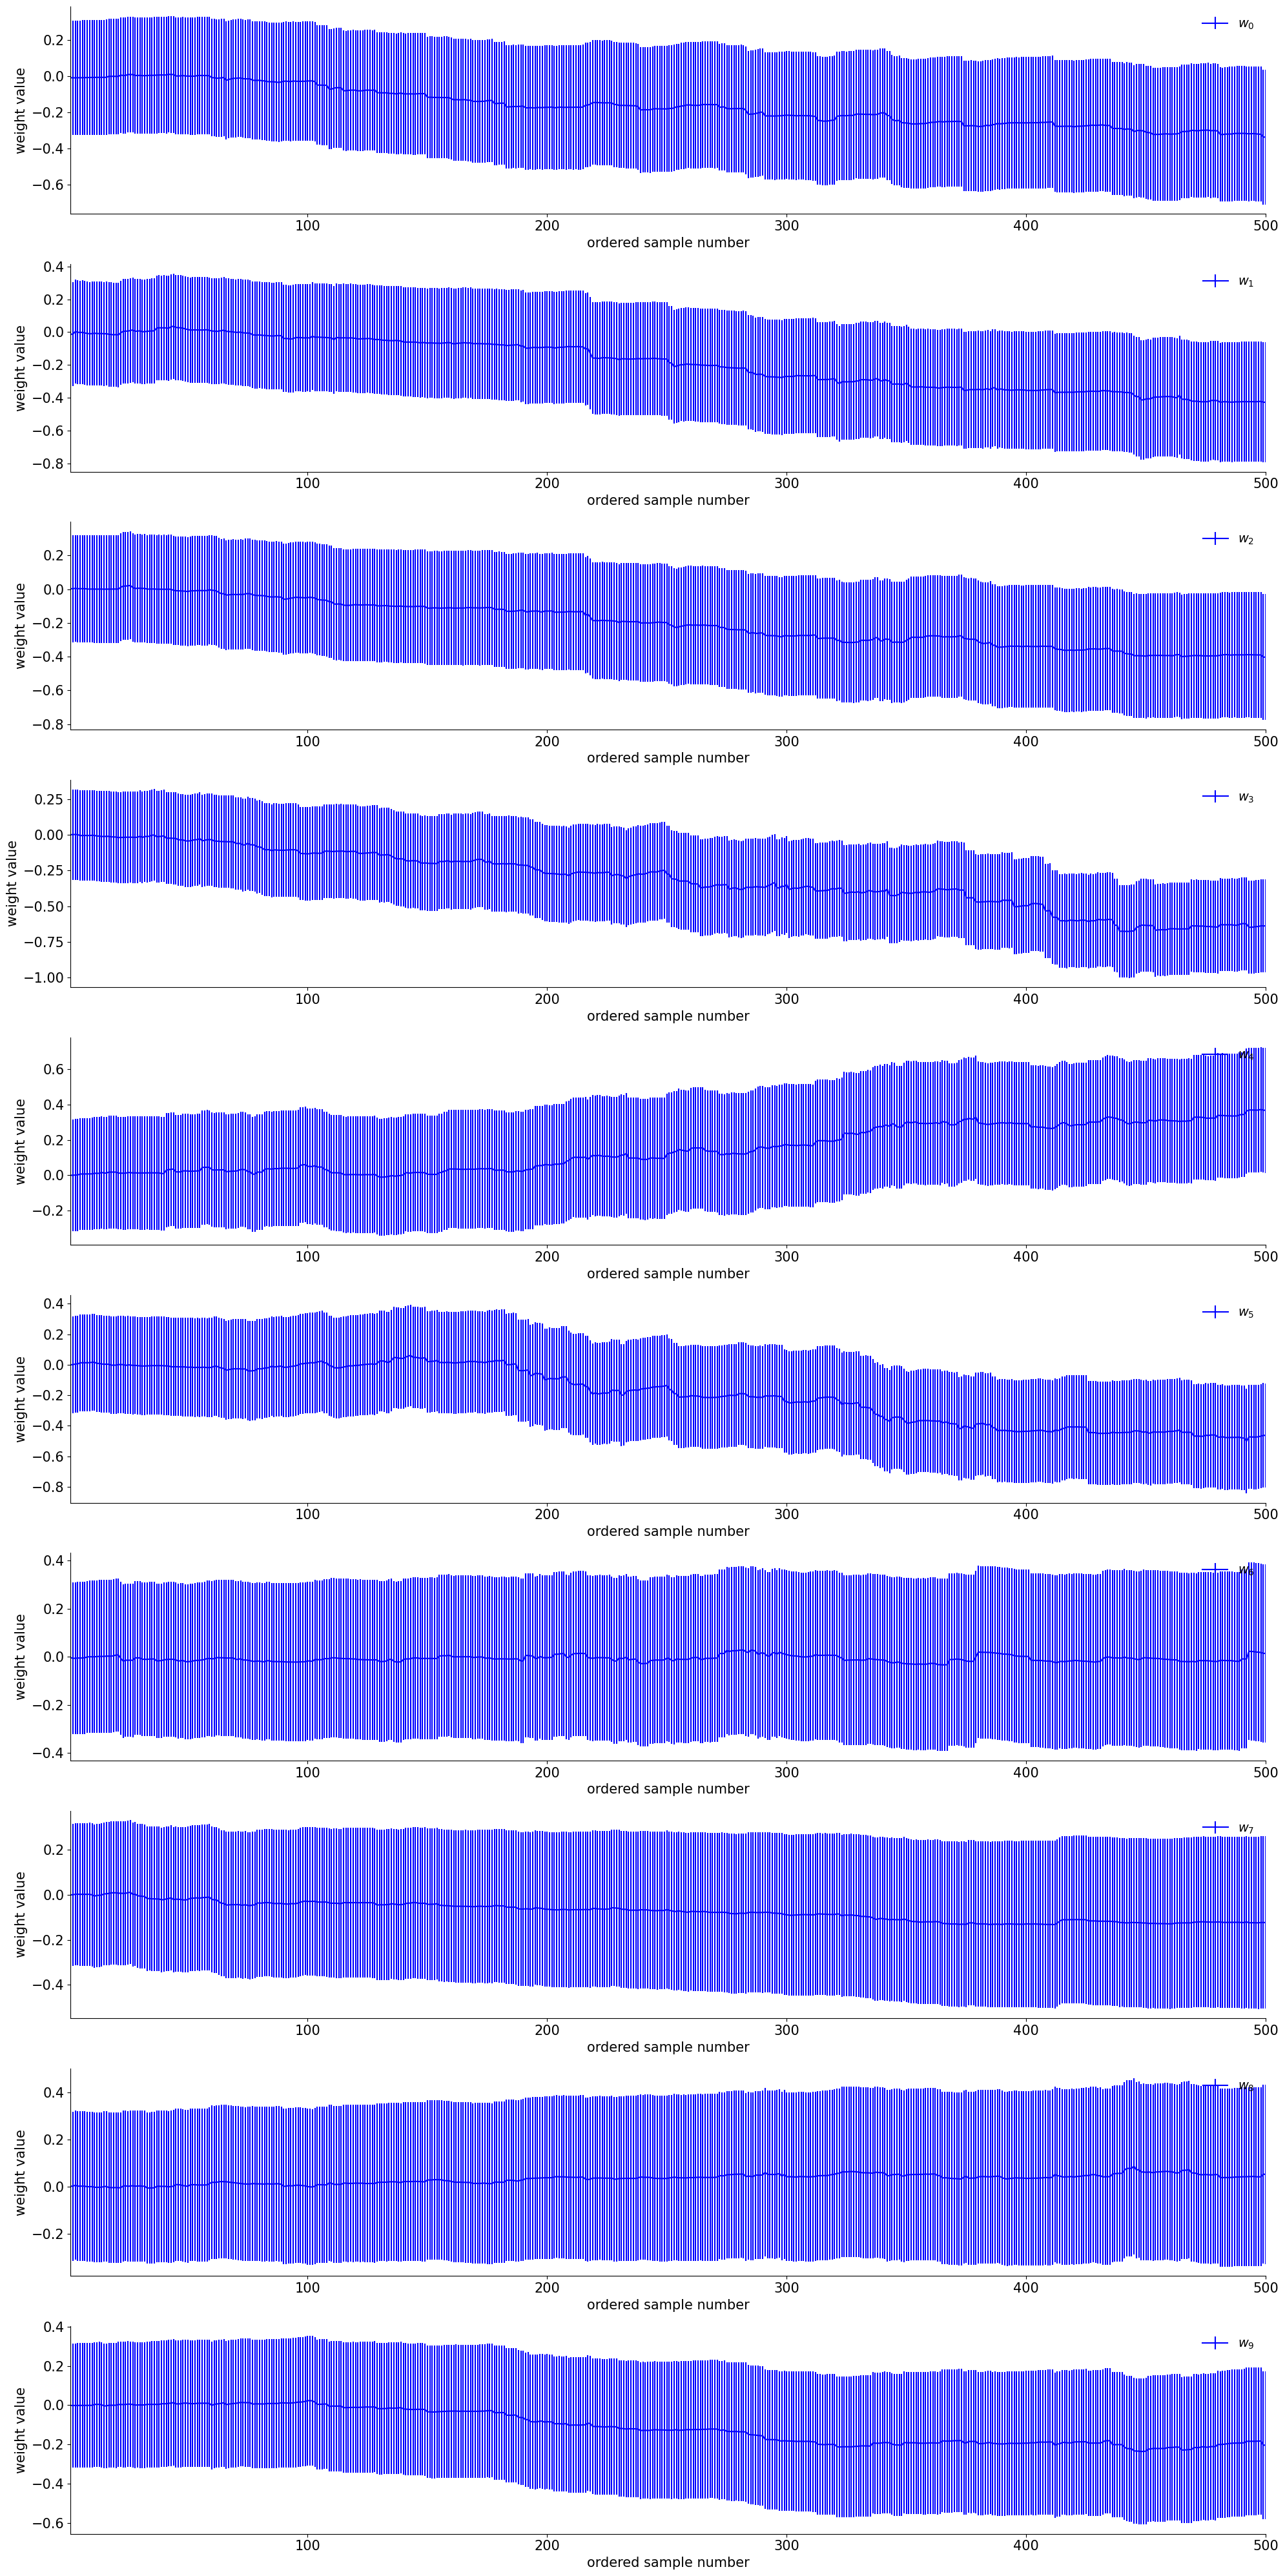

In [ ]:
# Function to visualise the Weights converging
plot_weight_convergence(w_means, w_covs)

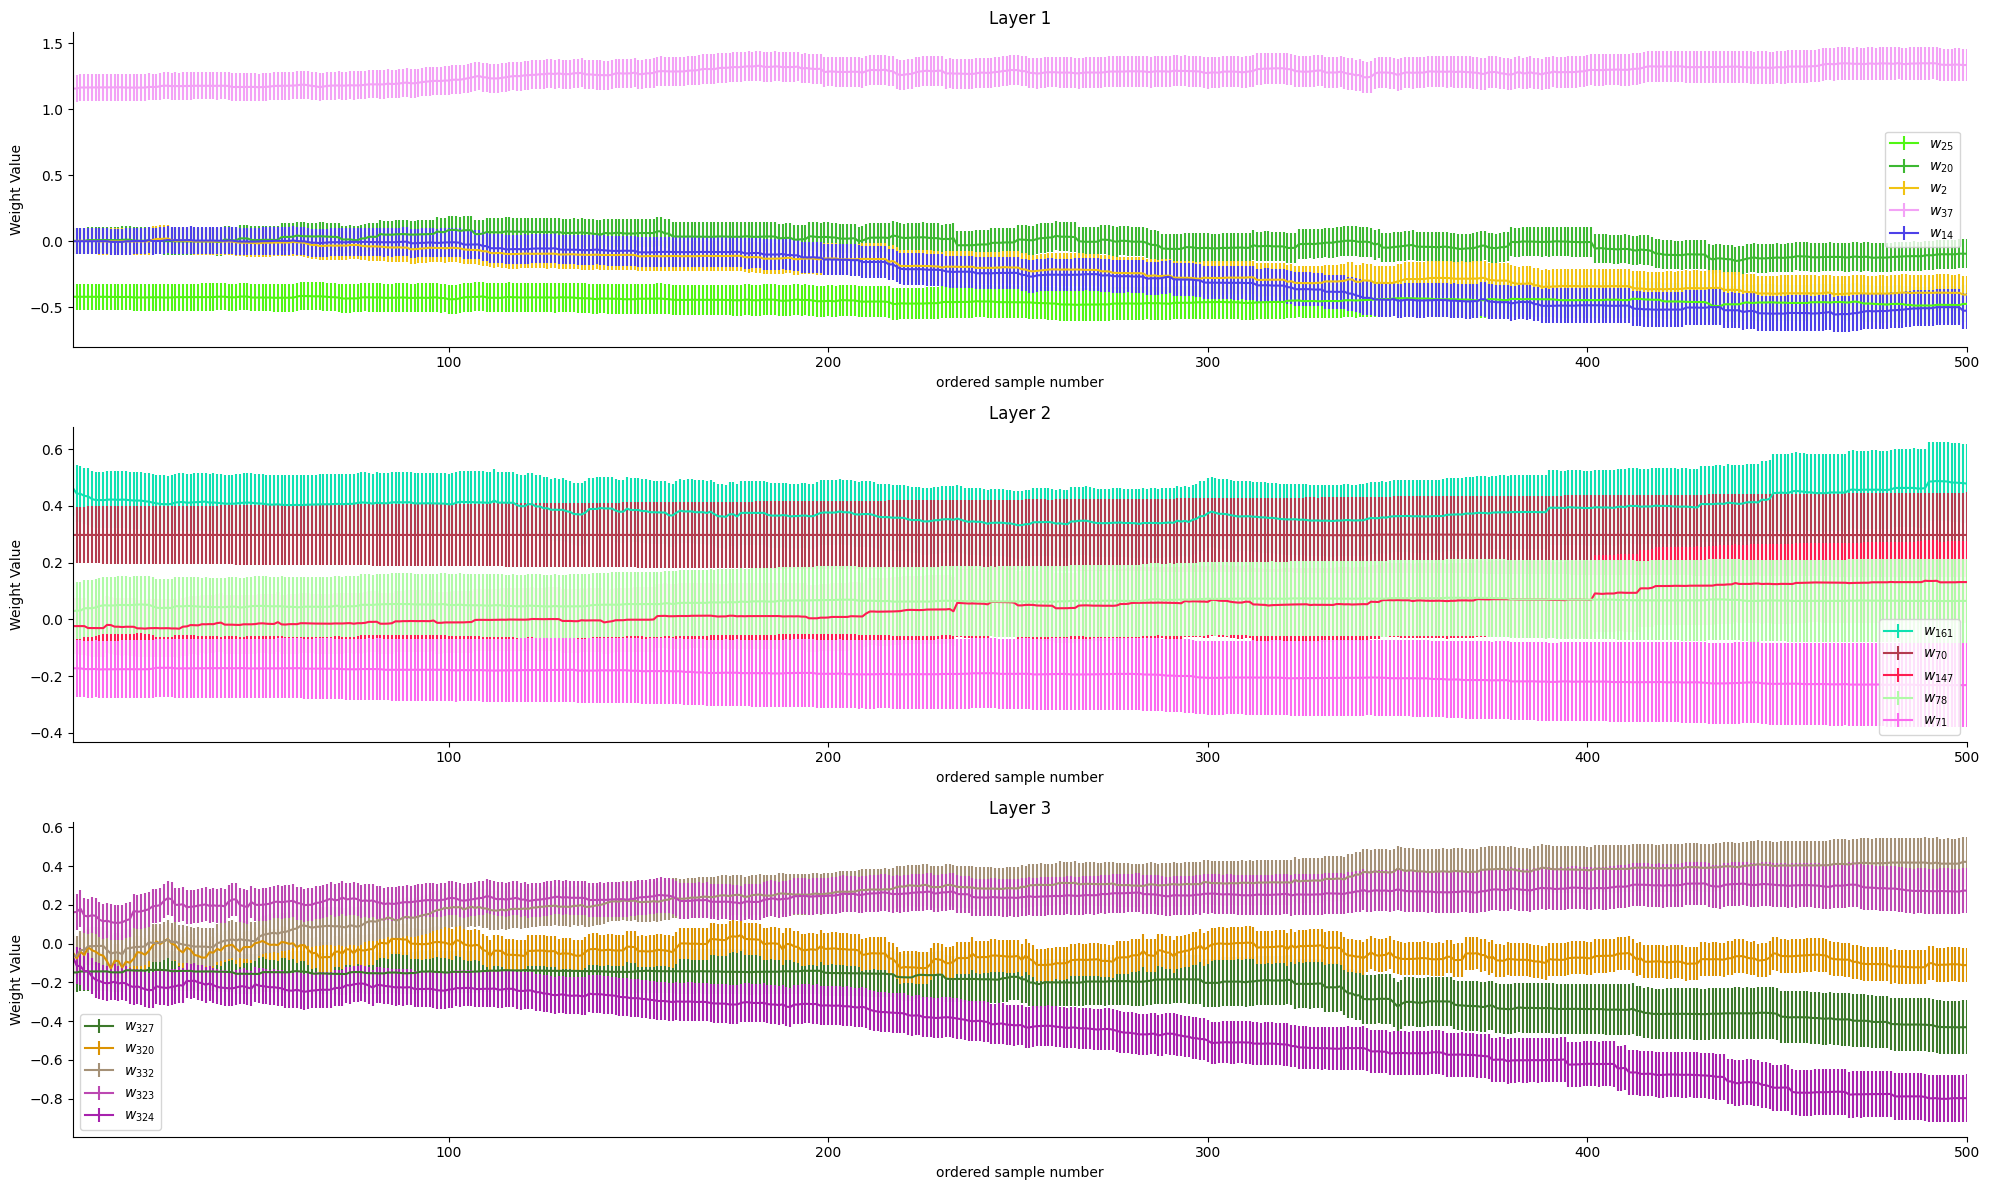

In [ ]:
# Code that prints all weights for first layer, then second layer, then third layer
plot_weights(model_dims, w_means, w_covs, 5)

## 1.3 Generating and Visualizing Rotated Data  

- We generate a rotated version of the spiral dataset by applying a 90-degree rotation to the input data using `generate_rotated_dataset()`.
- The rotated data is then visualized using `plot_posterior_predictive()` to observe the effect of the transformation on the classification problem.


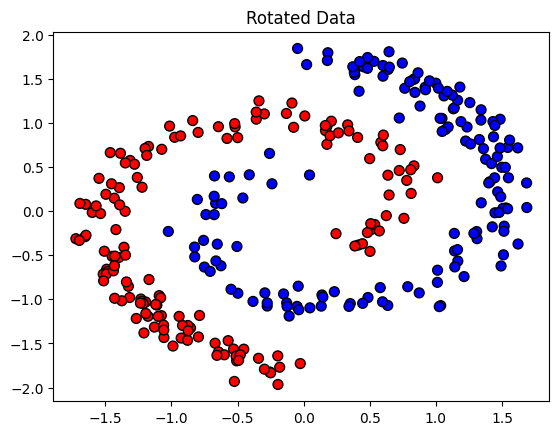

In [ ]:
# generate some rotated data

rot = 90 # in degrees
input_rot, output_rot = generate_rotated_dataset(rot = rot, num_per_class = 150)

# plot the data

fig, ax = plt.subplots()
title = 'Rotated Data'
plot_posterior_predictive(ax, input_rot, output_rot, title);

## 1.4 Retraining the MLP Classifier on Rotated Data  

- The MLP classifier, initially trained on the spiral data, is retrained using the Extended Kalman Filter (EKF) on the rotated dataset.
- The resulting classifier's performance is evaluated and visualized with the posterior predictive grid, showing the model's adaptation to the rotated data.  


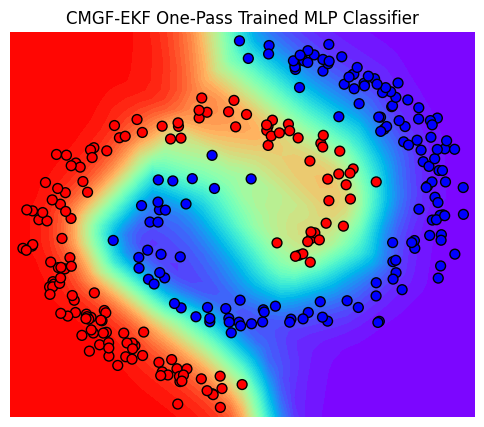

In [ ]:
from cnn_ekf.scripts.mlp_ekf_retraining import MLP_EKF_ReTraining


# Define grid limits
xmin, ymin = input_rot.min(axis=0) - 0.1
xmax, ymax = input_rot.max(axis=0) + 0.1

# Define grid
step = 0.1
x_grid, y_grid = jnp.meshgrid(jnp.mgrid[xmin:xmax:step], jnp.mgrid[ymin:ymax:step])
input_grid = jnp.concatenate([x_grid[...,None], y_grid[...,None]], axis=2)

# Create an instance of CNN_EKF_Training
mlp_ekf_retraining = MLP_EKF_ReTraining()

# Run the EKF
cmgf_ekf_post_rot = mlp_ekf_retraining.run_mlp_ekf(output_rot, input_rot, w_means[-1], w_covs[-1])

# Extract history of filtered weight values
w_means_rot, w_covs_rot = cmgf_ekf_post_rot.filtered_means, cmgf_ekf_post_rot.filtered_covariances

# Evaluate the trained MLP on input_grid
Z_rot = posterior_predictive_grid(input_grid, w_means_rot[-1], sigmoid_fn, binary=False)

# Plot the final result
fig, ax = plt.subplots(figsize=(6, 5))
title = "CMGF-EKF One-Pass Trained MLP Classifier"
plot_posterior_predictive(ax, input_rot, output_rot, title, input_grid, Z_rot);

## 1.5 Visualizing the Retraining Process with Animation  

- This code animates and visualizes the retraining process of the MLP classifier.
- It shows how the EKF-based updates gradually improve the classifier's decision boundary over time, with visualizations for rotated datasets.
- The animation is saved as a video and displayed as an interactive HTML video.  


In [ ]:
 import matplotlib.animation as animation
 from IPython.display import HTML

In [ ]:
def animateSpec(i):
  ax.cla()
  if i + 1 + 150>= 500:
    if (i+1 + 150)%2 == 0:
          w_curr = cmgf_ekf_post_rot.filtered_means[i - 499 + 150]
          Zi = posterior_predictive_grid(input_grid, cmgf_ekf_post_rot.filtered_means[i - 499 + 150], sigmoid_fn, binary=False)
          title = f'EKF-DDN (500/500) + Rotated data ({i - 499 + 150}/150)'
          plot_posterior_predictive(ax, input_rot[:i - 499], output_rot[:i - 499 + 150], title, input_grid, Zi);
          return ax
    else:
        #do nothing
        w_curr = cmgf_ekf_post_rot.filtered_means[i - 499 - 1 + 150]
        Zi = posterior_predictive_grid(input_grid, cmgf_ekf_post_rot.filtered_means[i - 499 -1 + 150], sigmoid_fn, binary=False)
        title = f'EKF-DDN (500/500) + Rotated data ({i - 499 - 1 + 150}/150)'
        plot_posterior_predictive(ax, input_rot[:i - 499 - 1 + 150], output_rot[:i - 499 - 1 + 150], title, input_grid, Zi);
        return ax
  w_curr = w_means[i + 150]
  Zi = posterior_predictive_grid(input_grid, w_means[i + 150], sigmoid_fn)
  title = f'EKF-DDN ({i+1+150}/500)'
  plot_posterior_predictive(ax, input[:i+1 + 150], output[:i+1 + 150], title, input_grid, Zi)
  return ax

In [ ]:
def animate(i):
  ax.cla()
  if i + 1 >= 500:
          w_curr = cmgf_ekf_post_rot.filtered_means[i - 499]
          Zi = posterior_predictive_grid(input_grid, cmgf_ekf_post_rot.filtered_means[i - 499], sigmoid_fn, binary=False)
          title = f'EKF-DDN (500/500) + Rotated data ({i - 499}/300)'
          plot_posterior_predictive(ax, input_rot[:i - 499], output_rot[:i - 499], title, input_grid, Zi);
          return ax
  w_curr = w_means[i]
  Zi = posterior_predictive_grid(input_grid, w_means[i], sigmoid_fn)
  title = f'EKF-DDN ({i+1}/500)'
  plot_posterior_predictive(ax, input[:i+1], output[:i+1], title, input_grid, Zi)
  return ax

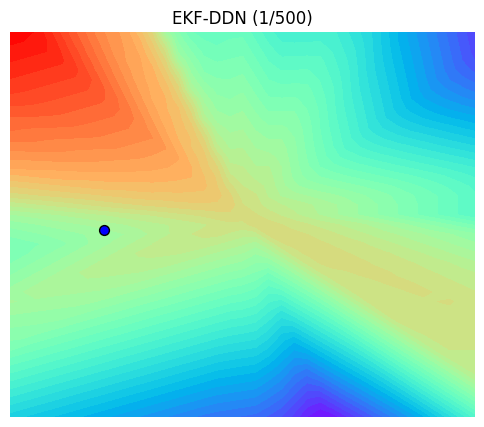

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))
anim = animation.FuncAnimation(fig, animate, frames=800, interval=50)
anim.save("cmgf_mlp_classifier.mp4", dpi=200, bitrate=-1, fps=15)

In [ ]:
HTML(anim.to_html5_video())

## 2. CNN with EKF Training for MNIST Dataset

#### Overview
This implementation applies the **Extended Kalman Filter (EKF)** to train a **Convolutional Neural Network (CNN)** on the MNIST dataset (classes `[0, 1]`). EKF is used to iteratively update model parameters while tracking their uncertainty.

#### Key Steps

1. **Data Loading**:
   The MNIST dataset is filtered to classes `[0, 1]` for binary classification.

2. **CNN Model**:
   The CNN model consists of two convolutional layers, average pooling, and fully connected layers, outputting a class prediction.

3. **EKF Training**:
   The `CNN_EKF_Training` class implements EKF, initializing the model parameters and covariance. The EKF uses a **dynamics function** (identity) and an **emission function** (sigmoid) for model updates.

4. **CMGF for Weight Update**:
   The **Conditional Moments Gaussian Filter (CMGF)**, a variant of EKF, refines the model's parameters based on observed outputs and their uncertainties.

5. **Model Output**:
   After training, the updated weights (means and covariances) are used to obtain the final model, improving prediction accuracy while accounting for parameter uncertainty.

#### Key Concepts
- **EKF**: Iteratively refines parameter estimates and tracks uncertainty.
- **CMGF**: A variant of EKF for refining weights in dynamic models.


In [ ]:
# Helper function to load specific classes of MNIST dataset
X_train, y_train, X_test, y_test = load_mnist_data_filtered([0, 1])

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training set shape: (12665, 28, 28, 1), Labels: [0 1]
Test set shape: (2115, 28, 28, 1), Labels: [0 1]


In [ ]:
from cnn_ekf.scripts.cnn_ekf_training import CNN_EKF_Training

cnn_ekf_trainer = CNN_EKF_Training()
w_means_old, w_covs, model_trained = cnn_ekf_trainer.run_cnn_ekf(X_train, y_train, 200)

## 2.1 Model Prediction and Evaluation

- After training, the model is evaluated on the test dataset. The prediction function applies a sigmoid activation to the model output and classifies inputs based on a threshold of 0.5. JAX's just-in-time (JIT) compilation is used for efficient computation.

- The model's accuracy is calculated on the test dataset, and predictions are displayed to visualize the results.

- Remarkably, the model achieves an accuracy of over **99%** after training with just **200 samples**. This demonstrates the efficiency and effectiveness of training using the **Conditional Moments Gaussian Filter (CMGF)** and **Extended Kalman Filter (EKF)**, allowing for rapid and robust learning with limited data.


Accuracy on the test set: 99.60%


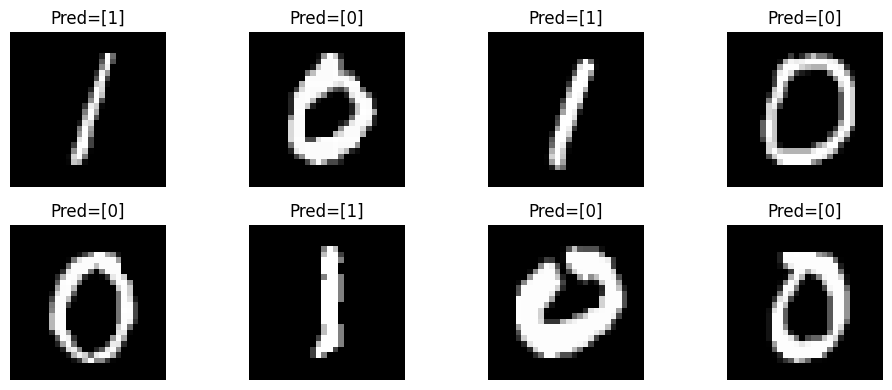

In [ ]:
@jax.jit
def predict_fn(x):
    return jnp.where(jax.nn.sigmoid(model_trained(x)) < 0.5, 0, 1)

predictions = calculate_accuracy(X_test, y_test, predict_fn)
display_predictions(X_test, predictions)

## 2.2 Plotting Weight Convergence

The helper functions visualize the convergence of weight estimates during training.

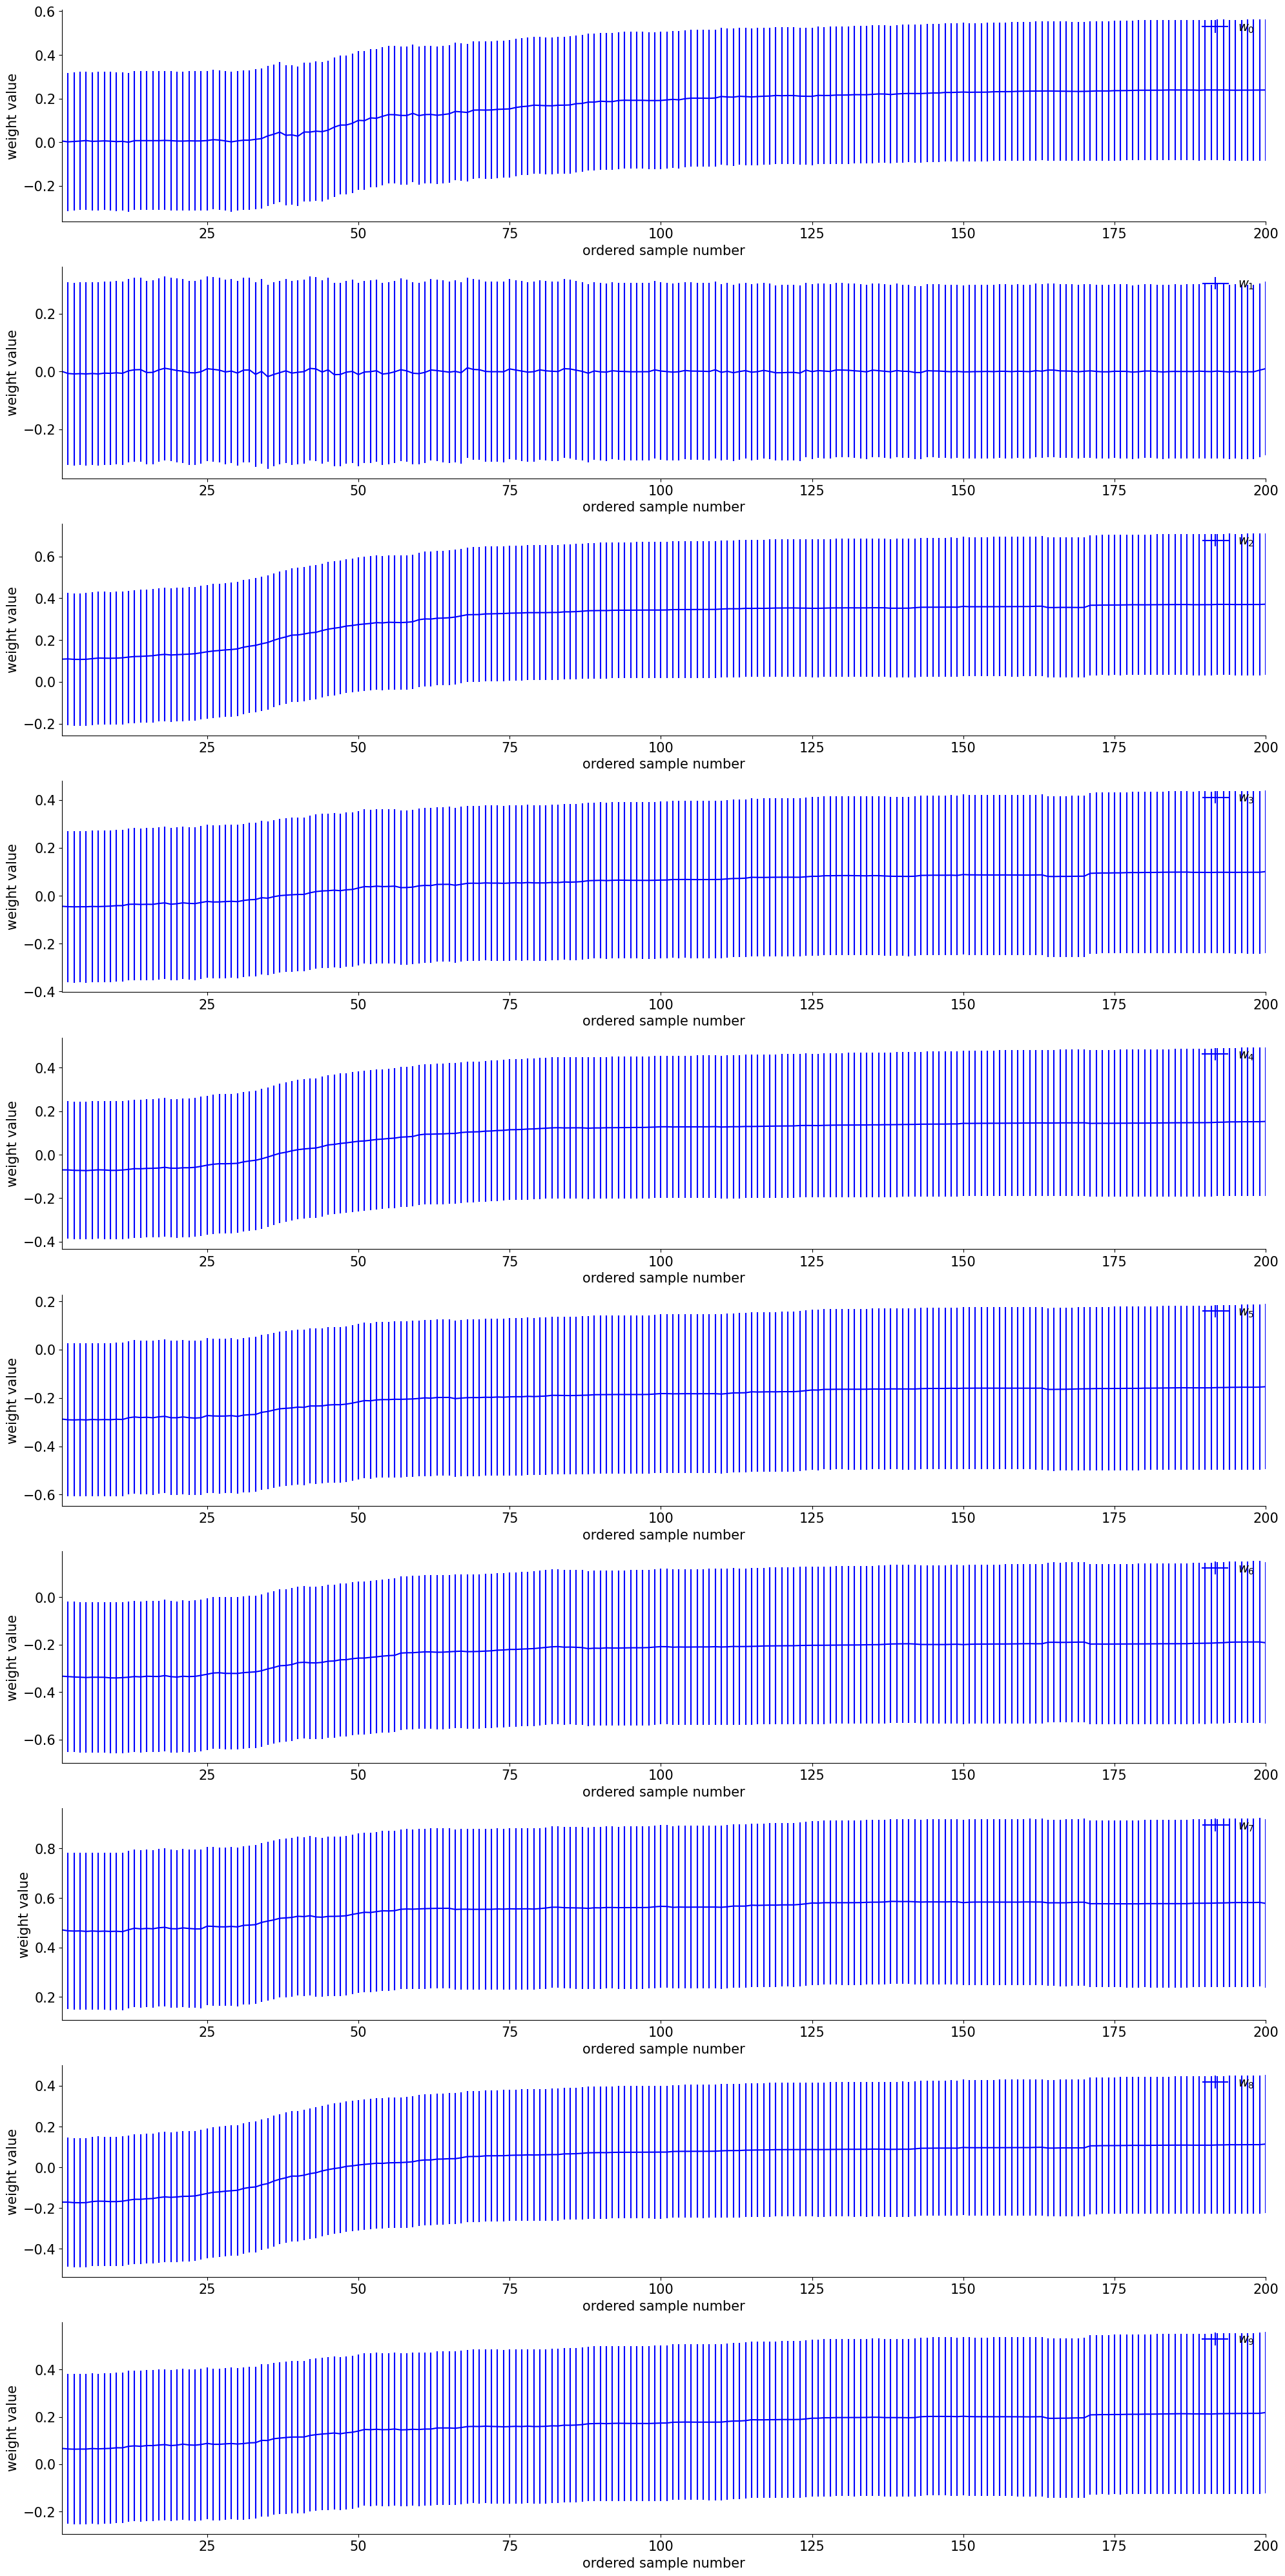

In [ ]:
# Function to visualise the Weights converging
plot_weight_convergence(w_means_old, w_covs)

## 2.3 Predictions on New Samples with Old Model
- Load the train and test data for classes 2 & 3.
- Evaluate predictions on new samples from MNIST data for classes 2 & 3.
- Use the model trained on classes 0 & 1 to make predictions, **achieving an expected accuracy of around 50%**.
- Later, a retrained model will be used to make predictions on the test data to validate the effectiveness of the re-training approach.

In [ ]:
# Load the MNIST data for classes 2 & 3
X_train, y_train, X_test, y_test = load_mnist_data_filtered([2, 3], convert_binary = True)

Training set shape: (12089, 28, 28, 1), Labels: [0 1]
Test set shape: (2042, 28, 28, 1), Labels: [2 3]


Accuracy on the test set: 54.70%


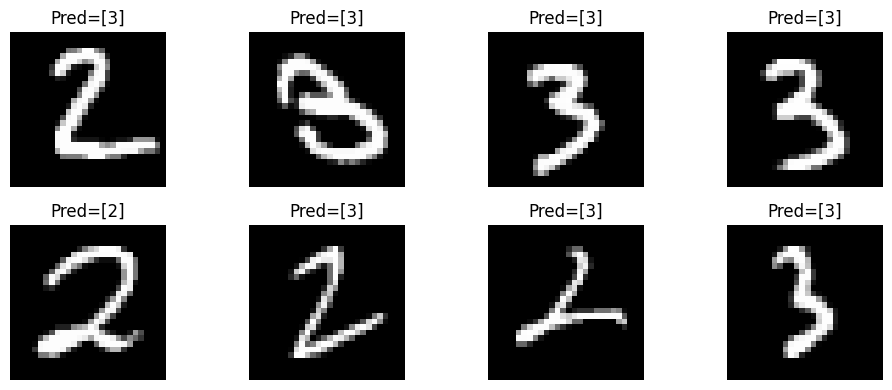

In [ ]:
# Old model, which is trained on classes 0 & 1 is used here for predictions
@jax.jit
def predict_fn(x):
    return jnp.where(jax.nn.sigmoid(model_trained(x)) < 0.5, 2, 3)

predictions = calculate_accuracy(X_test, y_test, predict_fn)
display_predictions(X_test, predictions)

## 2.4 Freezing Convolutional Layers and Retraining Linear Layers on classe 2 & 3

To adapt the trained CNN model to new classes (digits 2 and 3), the convolutional layer parameters are frozen, and only the linear layers are retrained.

### Process:
1. **Extracting Parameters:**  
   - The convolutional layer parameters are extracted and kept unchanged.  
   - The linear layer parameters are flattened for retraining.  

2. **Defining Training Strategy:**  
   - The training process ensures that previously learned feature representations remain intact.  
   - The linear layers are updated to classify the new digit classes efficiently.  

3. **Retraining on New Classes (Digits 2 and 3):**  
   - The model is trained on a filtered MNIST dataset containing only digits 2 and 3.  
   - The updated parameters are integrated back into the model while preserving prior knowledge.  

This approach enables efficient transfer learning, ensuring that previously learned convolutional features remain useful while adapting to new data.


In [ ]:
from flax import nnx

# helper function to provide flattened_params

def get_cnn_params(model):
  conv1_kernel = model.conv1.kernel.value.flatten()
  conv1_bias = model.conv1.bias.value.flatten()
  conv2_kernel = model.conv2.kernel.value.flatten()
  conv2_bias = model.conv2.bias.value.flatten()
  conv_params = jnp.concatenate([conv1_bias, conv1_kernel, conv2_bias, conv2_kernel])
  return conv_params

def get_linear_params(model):
  linear1_kernel = model.linear1.kernel.value.flatten()
  linear1_bias = model.linear1.bias.value.flatten()
  linear2_kernel = model.linear2.kernel.value.flatten()
  linear2_bias = model.linear2.bias.value.flatten()
  linear_params = jnp.concatenate([linear1_bias, linear1_kernel, linear2_bias, linear2_kernel])
  return linear_params

def get_flattened_params(model):
    # Define CNN model
    graphdef, state = nnx.split(model)
    flat_params, unflatten_fn = ravel_pytree(state)

    # Define apply function
    def apply(linear_params, x, model, graphdef, unflatten_fn):
      conv_params = get_cnn_params(model)
      flat_params = jnp.concatenate([conv_params, linear_params])
      model = nnx.merge(graphdef, unflatten_fn(flat_params))
      return model(x)

    apply_fn = partial(apply, model=model, graphdef=graphdef, unflatten_fn=unflatten_fn)

    return model, flat_params, unflatten_fn, apply_fn, graphdef

model_trained, flat_params, unflatten_fn, apply_fn, graphdef = get_flattened_params(model_trained)

In [ ]:
initial_mean = get_linear_params(model_trained)
state_dim = initial_mean.size
softmax_fn = lambda w, x: jax.nn.sigmoid(apply_fn(w, x)) # softmax for more classes
initial_sigma2 = 0.1 #1e-1
dynamic_sigma = 1e-4 #1e-4

# Run CMGF-EKF to train the MLP Classifier
initial_covariance=jnp.eye(state_dim) * initial_sigma2
dynamics_function=lambda w, x: w
dynamics_covariance=jnp.eye(state_dim) * dynamic_sigma
emission_mean_function = lambda w, x: softmax_fn(w, x)

emission_cov_function = lambda w, x: softmax_fn(w, x) * (1 - softmax_fn(w, x))

cmgf_ekf_params = ParamsGGSSM(
    initial_mean = initial_mean,
    initial_covariance = initial_covariance,
    dynamics_function = dynamics_function,
    dynamics_covariance = dynamics_covariance,
    emission_mean_function = emission_mean_function,
    emission_cov_function = emission_cov_function
)

input = X_train[:200,]
output = y_train[:200].astype(jnp.float32)
cmgf_ekf_post = conditional_moments_gaussian_filter(cmgf_ekf_params, EKFIntegrals(), output, inputs=input)

# Extract history of filtered weight values
w_means_new, w_covs = cmgf_ekf_post.filtered_means, cmgf_ekf_post.filtered_covariances
post_mean, post_cov = w_means_new[-1], w_covs[-1]

cnn_params = get_cnn_params(model_trained)
total_params = jnp.concatenate([cnn_params, post_mean])
model_retrained = nnx.merge(graphdef, unflatten_fn(total_params))

## 2.5 Plotting weights Adaptation

This helper function helps anlyse the re-training of linear parameters **before and after the adaptation to new classes**.

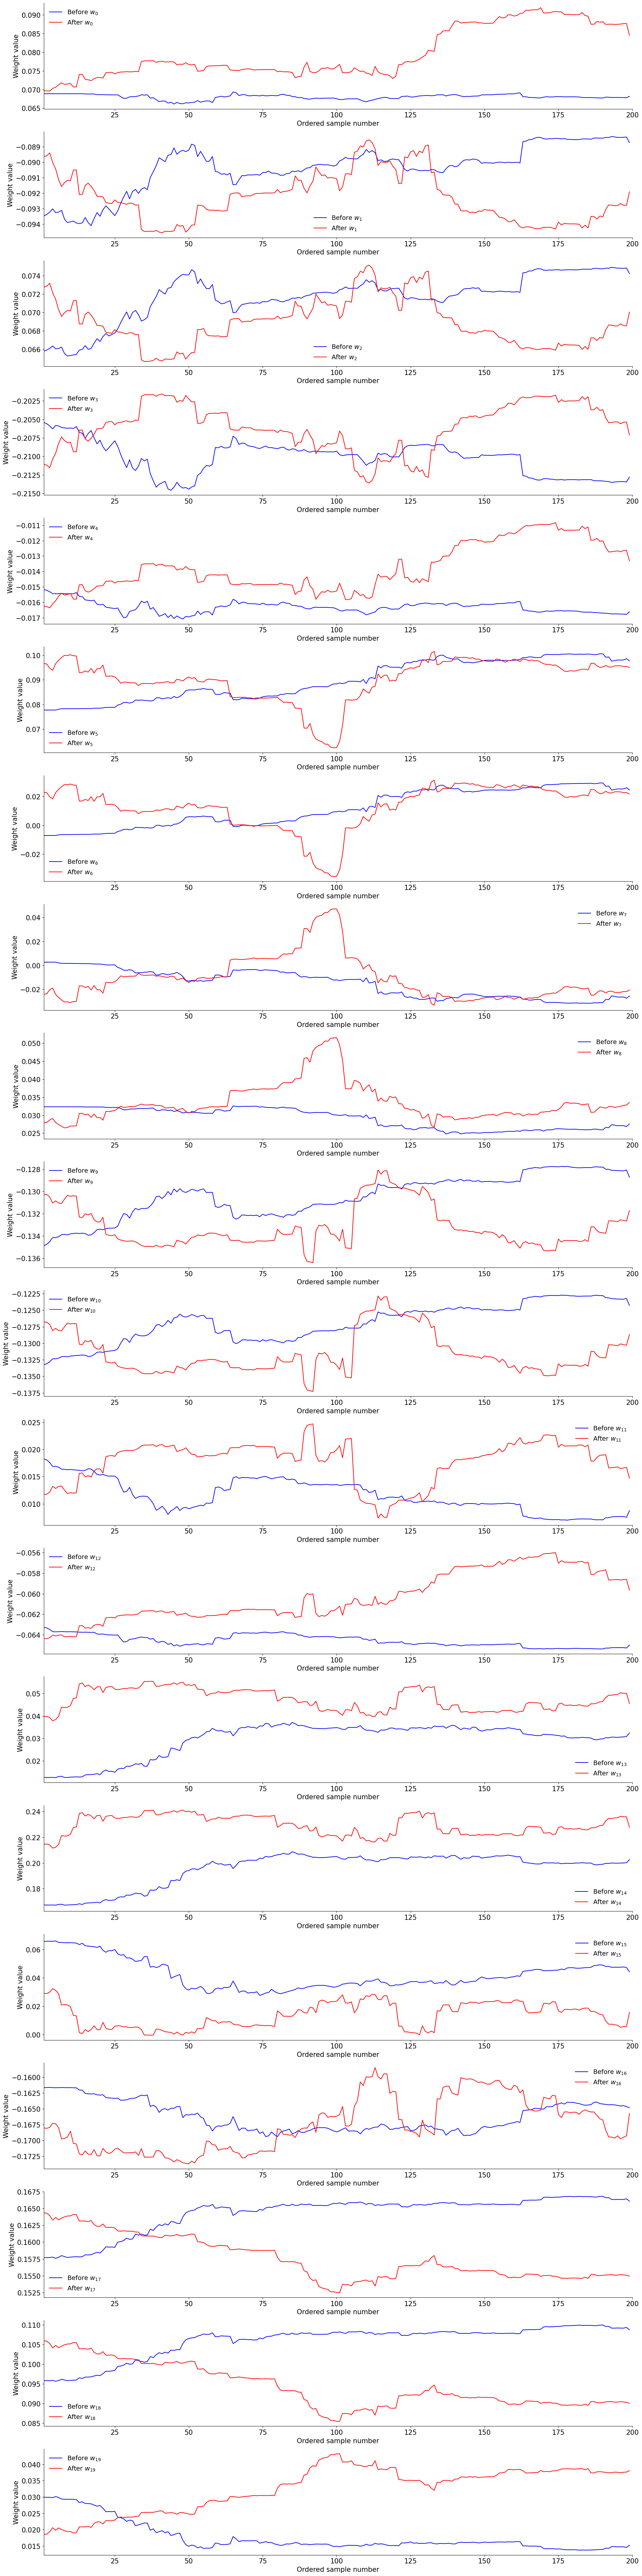

In [ ]:
 #Filter for last 50 weights to ensure same weights are chosen in both w_means
plot_weight_changes(w_means_old[:,-50:], w_means_new[:,-50:])

## 2.6 Model Prediction and Evaluation

- After retraining the model with frozen convolution parameters and updating only the linear parameters, **the accuracy improves from around 50% to 95% while using less than half the training samples**. This validates our expectation that adapting trained parameters to different classes can be effectively achieved by retraining only the linear parameters, while the convolutional layers retain useful feature representations from previous training.

- The prediction function applies a sigmoid activation to the model output and classifies inputs based on a threshold of 0.5. JAX's just-in-time (JIT) compilation is used for efficient computation.

- The model's accuracy is calculated on the test dataset, and predictions are displayed to visualize the results.

Accuracy on the test set: 95.60%


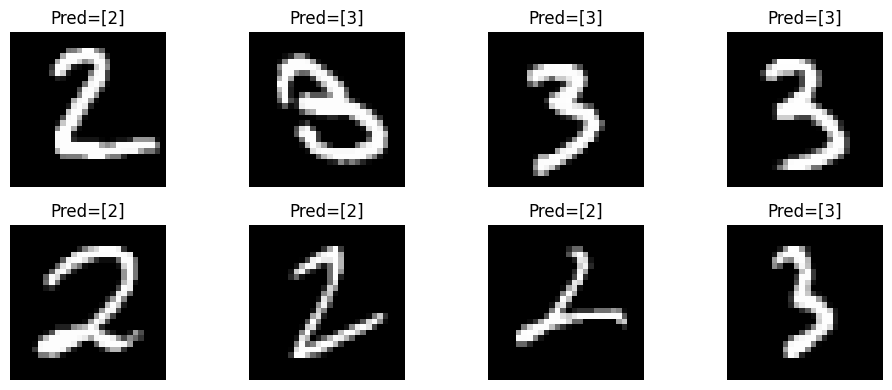

In [ ]:
@jax.jit
def predict_fn(x):
    return jnp.where(jax.nn.sigmoid(model_retrained(x)) < 0.5, 2, 3)

predictions = calculate_accuracy(X_test, y_test, predict_fn)
display_predictions(X_test, predictions)